In [26]:
## Impoting necessary Libraries, tools and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## scikit learn libraries 
from sklearn.datasets import fetch_california_housing 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,RidgeCV,LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



In [27]:
## Dataloading and overviewing 
california= fetch_california_housing(as_frame=True)
# california.DESCR
df=california.frame
df.head(10)
df.info()  ## To check for any null columns 
df.describe

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


<bound method NDFrame.describe of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

     

In [28]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


<Axes: xlabel='Count', ylabel='MedHouseVal'>

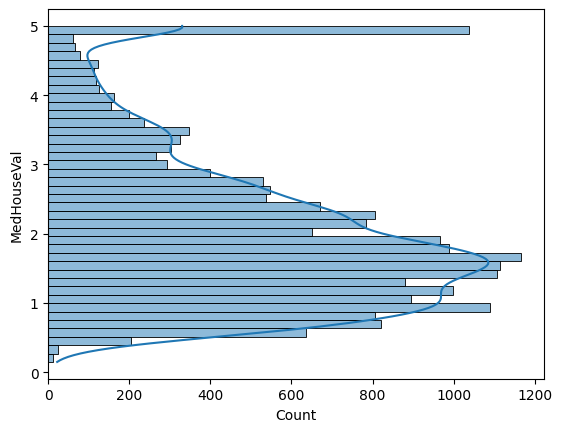

In [29]:
## Perform Exploratory Data Analysis To understand the data and  relationships between the features better
##  plot histogram of the target variable(MedHouseVal)
sns.histplot(y=df['MedHouseVal'],bins=40,kde=True)

<Axes: >

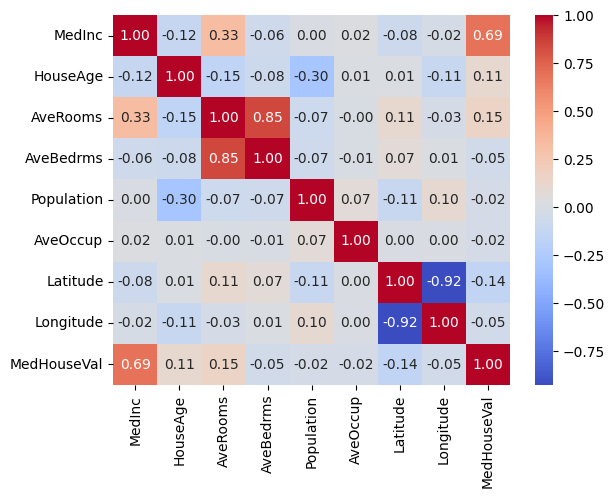

In [30]:
## # TODO: Plot a correlation matrix heatmap to see which features correlate most with MedHouseVal
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

1.Median Income feature is the most important feature and highly correlated to the target Median House value. 
2.AveRooms and AveBedrooms are highly correlated it can cause multicolinearity one of them could be dropped ?
3. Population, Aveoccup Lattitude and longitude features are close to zero and dont effect the target Median House Value.
4. Longitude n latitude has high negative correlation.
5. Median Income and AveRooms also have a moderate correlation , indicating higher median income gives more buying power and hence has bigger homes

In [31]:
## Data Preprocessing 
## Seperate feature X and Target Y 
X= df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']

In [32]:
## Split Test and Train Data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
## We need to standardize the Data 
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [34]:
## Initialize n train the model 
Lin_reg=LinearRegression()
Lin_reg.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
## Lets predict 
y_pred=Lin_reg.predict(X_test_scaled)
## Evaluate the model 
MAE=mean_absolute_error(y_test,y_pred)
RMSE=mean_squared_error(y_test,y_pred)
R2=r2_score(y_test,y_pred)
print(f"ML Model MAE: {MAE:.2f}")
print(f" ML Model RMSE: {RMSE:.2f}")
print(f" ML Model R-Squared: {R2:.2f}")

ML Model MAE: 0.54
 ML Model RMSE: 0.54
 ML Model R-Squared: 0.59


In [40]:
##Lets check Weights of the feature 
Weights_Feature=pd.DataFrame({
    "Feature" : X_train.columns,
    "Weights" : Lin_reg.coef_
})

Weights_Feature.head(10)

,Feature,Weights
0,MedInc,0.854383
1,HouseAge,0.122546
2,AveRooms,-0.294410
3,AveBedrms,0.339259
4,Population,-0.002308
5,AveOccup,-0.040829
6,Latitude,-0.896929
7,Longitude,-0.869842


In [43]:
## Ridge L2 Regularization 
alpha=np.logspace(-4,4,100)
ridge_model=RidgeCV(alphas=alpha,cv=5)
ridge_model.fit(X_train,y_train)
##Lets check Weights of the feature again
RidgeWeights=pd.DataFrame({
    "Feature" : X_train.columns,
    "Weights" : ridge_model.coef_
})

RidgeWeights.head(10)

,Feature,Weights
0,MedInc,0.447305
1,HouseAge,0.009739
2,AveRooms,-0.120740
3,AveBedrms,0.768700
4,Population,-0.000002
5,AveOccup,-0.003523
6,Latitude,-0.419733
7,Longitude,-0.433467


In [44]:
## Lasso L1 Regularization 
alpha=np.logspace(-4,4,100)
lasso_model=LassoCV(alphas=alpha,cv=5,max_iter=20000)
lasso_model.fit(X_train,y_train)
##Lets check Weights of the feature again
lassoWeights=pd.DataFrame({
    "Feature" : X_train.columns,
    "Weights" : lasso_model.coef_
})

lassoWeights.head(10)

,Feature,Weights
0,MedInc,0.446913
1,HouseAge,0.009750
2,AveRooms,-0.119962
3,AveBedrms,0.764549
4,Population,-0.000002
5,AveOccup,-0.003519
6,Latitude,-0.419229
7,Longitude,-0.432875


In [46]:
lasso_weights = lasso_model.coef_
lasso_weights

array([ 4.46913024e-01,  9.75015900e-03, -1.19962240e-01,  7.64548555e-01,
       -1.95330695e-06, -3.51892963e-03, -4.19229374e-01, -4.32875065e-01])